In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

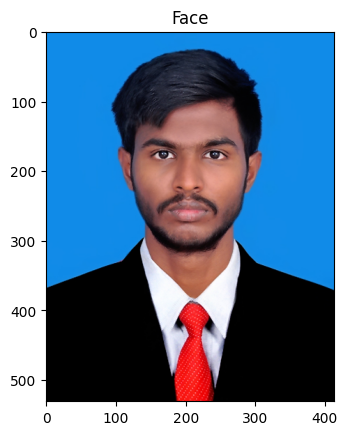

In [2]:
# Load the Face Image
faceImage = cv2.imread("Aaron photo.jpg")
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [3]:
faceImage.shape

(531, 413, 3)

In [4]:
#resized_faceImage.shape
faceImage.shape

(531, 413, 3)

Text(0.5, 1.0, 'glassPNG')

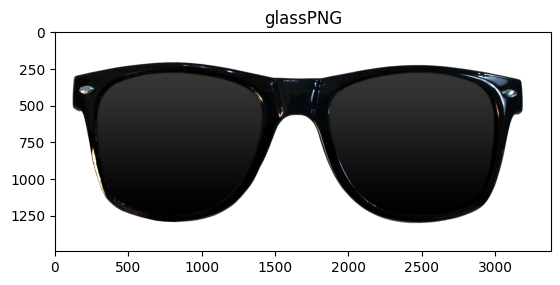

In [5]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread("Image-Source-PlusPNG.com.png",-1)
plt.imshow(glassPNG)
plt.title("glassPNG")

In [6]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(190,50))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(50, 190, 4)


In [7]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:4]
glassMask1 = glassPNG[:,:,3]

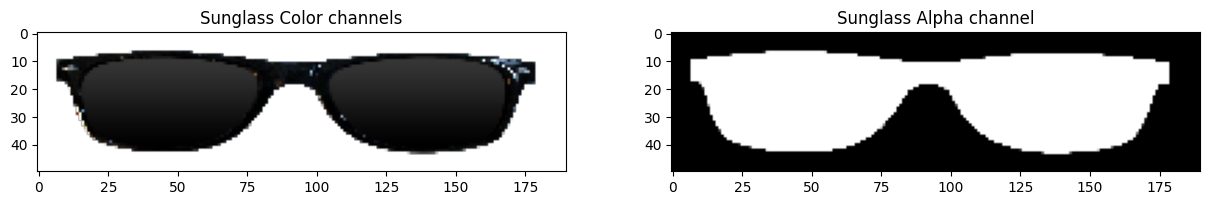

In [8]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

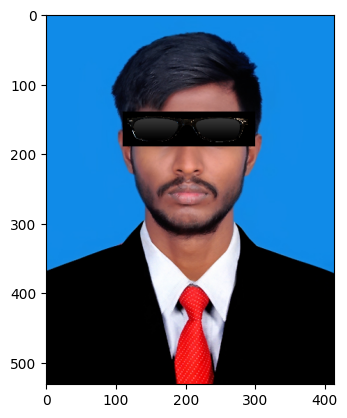

In [9]:
# Make a copy
#faceWithGlassesNaive = resized_faceImage.copy()
faceWithGlassesNaive = faceImage.copy()

# Replace the eye region with the sunglass image
faceWithGlassesNaive[140:190,110:300]=glassBGR[:, :, :3]

plt.imshow(faceWithGlassesNaive[...,::-1])

In [10]:
# Split channels (BGRA)
b, g, r, a = cv2.split(glassBGR)

# Create mask from alpha channel
glassMask1 = a

Text(0.5, 1.0, 'Final Output')

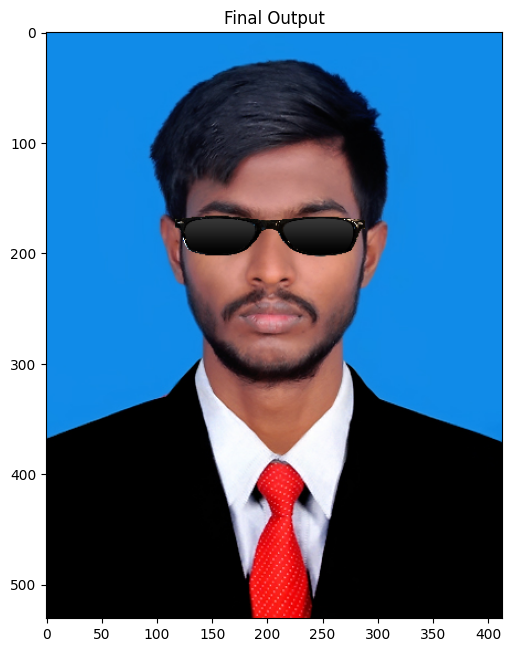

In [11]:


# Convert glass image to BGR (remove alpha)
glassBGR = cv2.merge((b, g, r))

# Resize glasses and mask to match ROI size (190 x 50)
glassBGR = cv2.resize(glassBGR, (190, 50))
glassMask1 = cv2.resize(glassMask1, (190, 50))

# Create 3-channel mask
glassMask = cv2.merge((glassMask1, glassMask1, glassMask1))

# Convert mask to float [0,1]
glassMask = glassMask / 255.0

# Copy face image
faceWithGlassesArithmetic = faceImage.copy()

# Extract ROI
eyeROI = faceWithGlassesArithmetic[160:210,110:300]

# Convert to float
eyeROI = eyeROI.astype(float)
glassBGR = glassBGR.astype(float)

# Apply mask
maskedEye = cv2.multiply(eyeROI, (1 - glassMask))
maskedGlass = cv2.multiply(glassBGR, glassMask)

# Add both
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Convert back to uint8
eyeRoiFinal = np.uint8(eyeRoiFinal)

# Place result back into image
faceWithGlassesArithmetic[160:210,110:300] = eyeRoiFinal

# Display results
plt.figure(figsize=[20,20])
# plt.subplot(131); plt.imshow(np.uint8(maskedEye)[...,::-1]); plt.title("Masked Eye Region")
# plt.subplot(132); plt.imshow(np.uint8(maskedGlass)[...,::-1]); plt.title("Masked Sunglass Region")
plt.subplot(133); plt.imshow(faceWithGlassesArithmetic[...,::-1]); plt.title("Final Output")

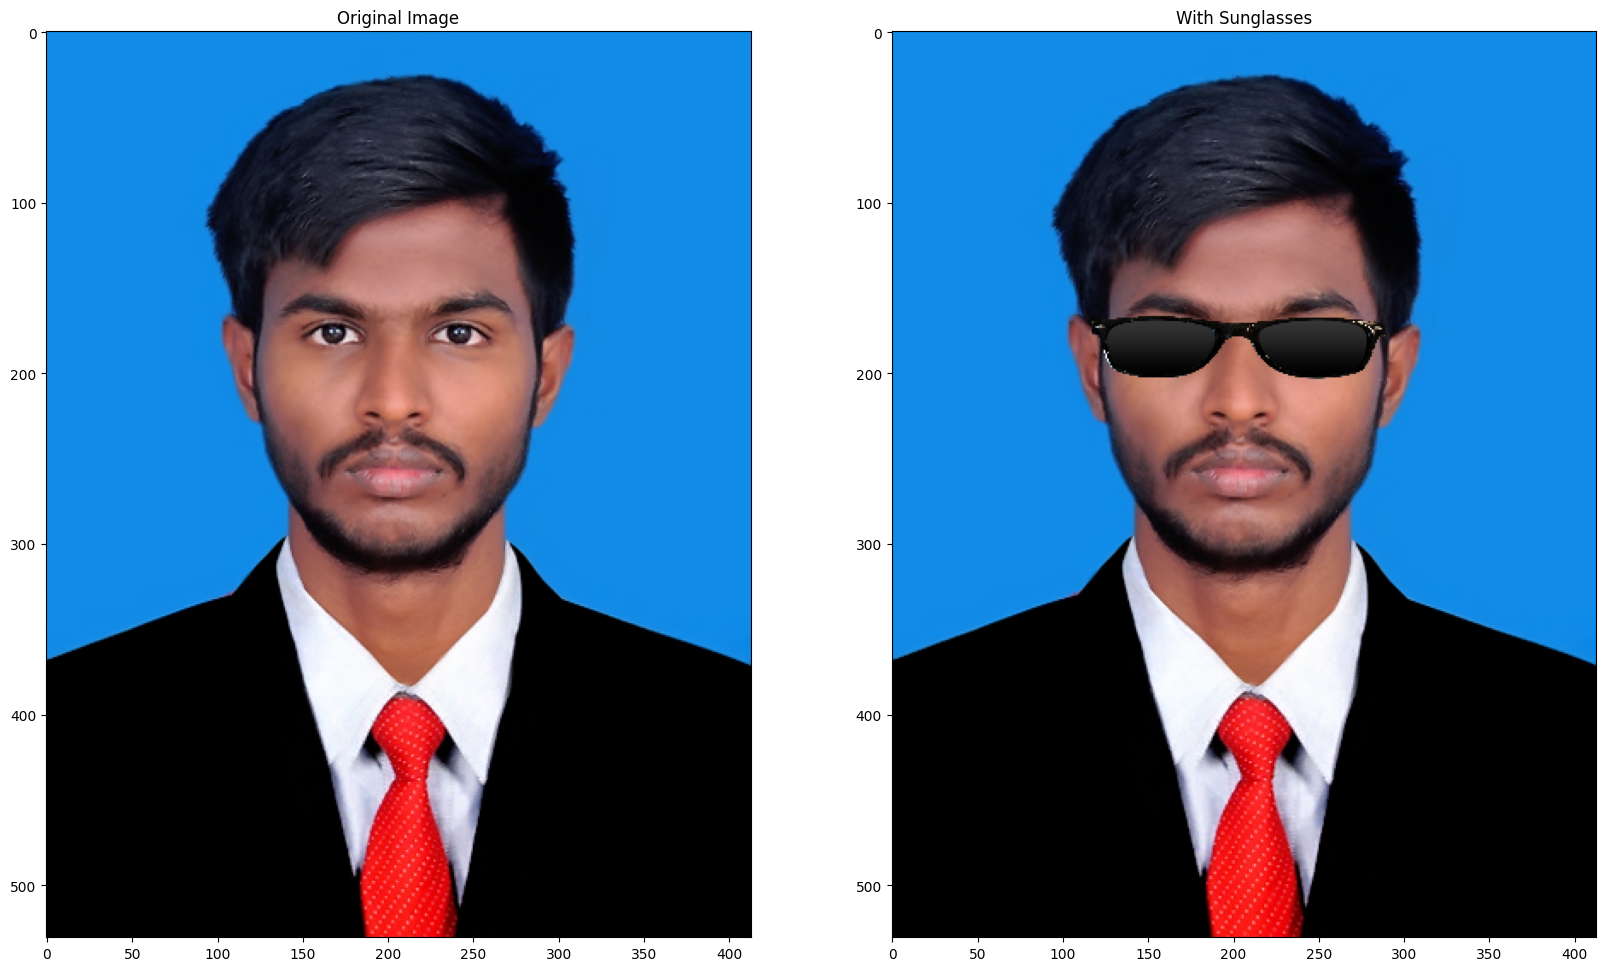

In [12]:
# Replace the eye ROI with the output from the previous section
# faceWithGlassesArithmetic[160:210,110:300]=eyeRoiFinal

# Display the final result
plt.figure(figsize=[20,20]);
plt.subplot(121);plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image");
plt.subplot(122);plt.imshow(faceWithGlassesArithmetic[:,:,::-1]);plt.title("With Sunglasses");